In this notebook, we test our method on a simple CNN with 1x2 convolution and 1x4 images.

In [152]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

In [3]:
from Meta_learning import MetaLearner
import Meta_loss_functions as mlf
from Visualization import plot_accuracy_comparison

The parameters we will train are the dataset elements themselves. The model consists of a 1×2 convolution with stride (1×2), followed by max pooling and a linear layer.

In [4]:
class Generator(nn.Module):
    def __init__(self, num_classes, n_per_class):
        super().__init__()
        self.num_classes = num_classes
        self.n_per_class = n_per_class
        self.data = nn.Parameter(
            0.1 * torch.randn(num_classes * n_per_class, 1, 1, 4)
        )

    def forward(self, z=None, y=None):
        return self.data

    def visualize(self, x=None, y=None, n_visualize=None):
        if x is None or y is None:
            x, y = self.generate_dataset()
        
        if n_visualize is None:
            n_visualize = self.n_per_class
        
        x = x.detach().cpu()
        y = y.detach().cpu()
        
        cols = min(n_visualize, self.n_per_class)
        rows = self.num_classes
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 0.8))
        
        if rows == 1:
            axes = np.expand_dims(axes, axis=0)
        if cols == 1:
            axes = np.expand_dims(axes, axis=1)
        
        for i in range(rows):
            class_indices = (y == i).nonzero(as_tuple=True)[0][:cols]
            
            for j in range(cols):
                if j < len(class_indices):
                    idx = class_indices[j]
                    ax = axes[i, j]

                    img = x[idx, 0, 0, :].numpy()
                    img_2d = img.reshape(1, -1)
                    
                    ax.imshow(img_2d, cmap="gray", vmin=0, vmax=1, aspect='auto')
                    ax.set_xticks([])
                    ax.set_yticks([])
                    
                    if j == 0:
                        ax.set_ylabel(f"Class {i}", fontsize=10)
                
                for spine in axes[i, j].spines.values():
                    spine.set_visible(True)
                    spine.set_color('black')
                    spine.set_linewidth(1)
        
        plt.subplots_adjust(wspace=0.3, hspace=0.3)
        plt.show()

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Conv2d(1, 1, kernel_size=(1, 2), stride=(1, 2))
        self.pool = nn.MaxPool2d(kernel_size=(1, 2))
        self.fc = nn.Linear(1, num_classes)
        
    def forward(self, x):
        x = F.leaky_relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

First try this with 2 classes and without any regularization term:

step: 483, meta_loss: 0.1076, accuracy: 100.00%


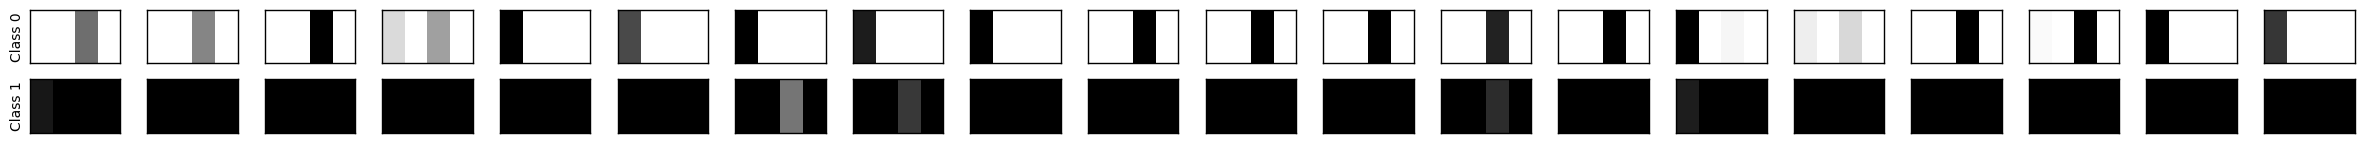

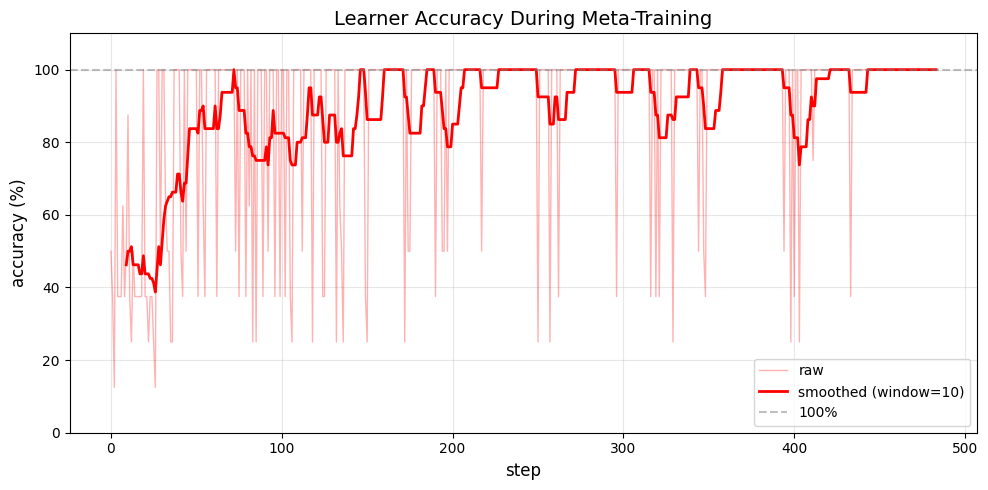

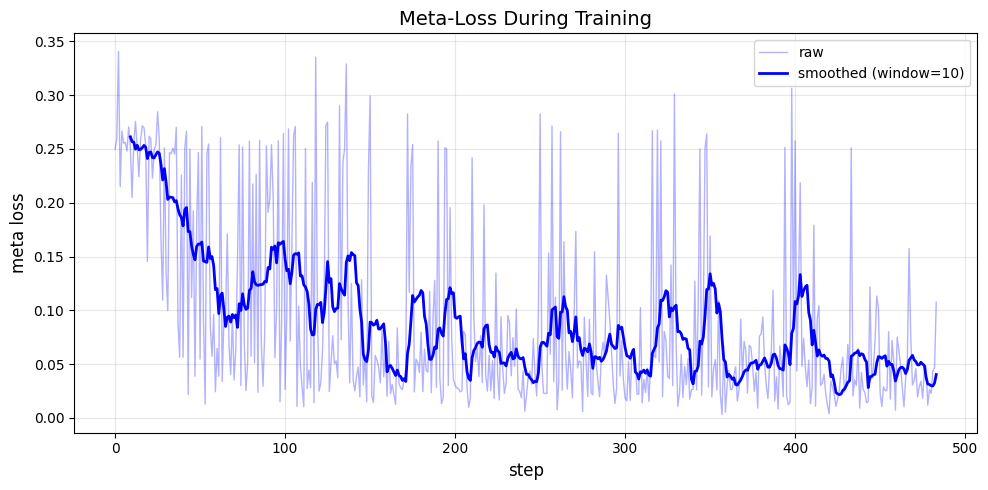

In [76]:
generator_without_reg = Generator(num_classes=2, n_per_class=20)

meta = MetaLearner(
    generator=generator_without_reg,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=2,
    n_per_class=20,
    meta_lr=0.05,
    inner_lr=0.5, 
    inner_steps=7,
    stop_after_consecutive_100=50
)

meta.train(steps=2000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()
acc_without_reg = meta.get_accuracy_history()

Even without regularization, the trivial solution (where all images within a class are identical) does not fully occur. This reveals the convolutional architecture's inductive bias towards locality — within a given class, we observe images where the first and second pairs of pixels are swapped. This indicates that for this architecture, local structure matters more than global structure.

Now, let us introduce regularization. We start with the average distance between classes.

step: 1025, meta_loss: 0.1259, accuracy: 100.00%


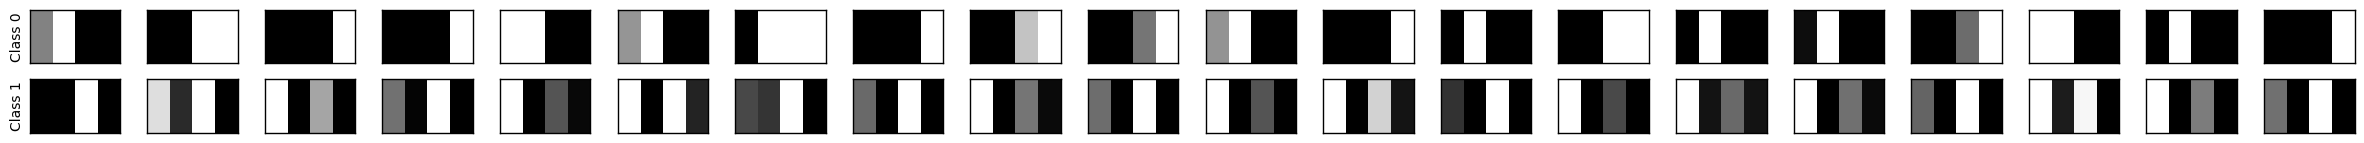

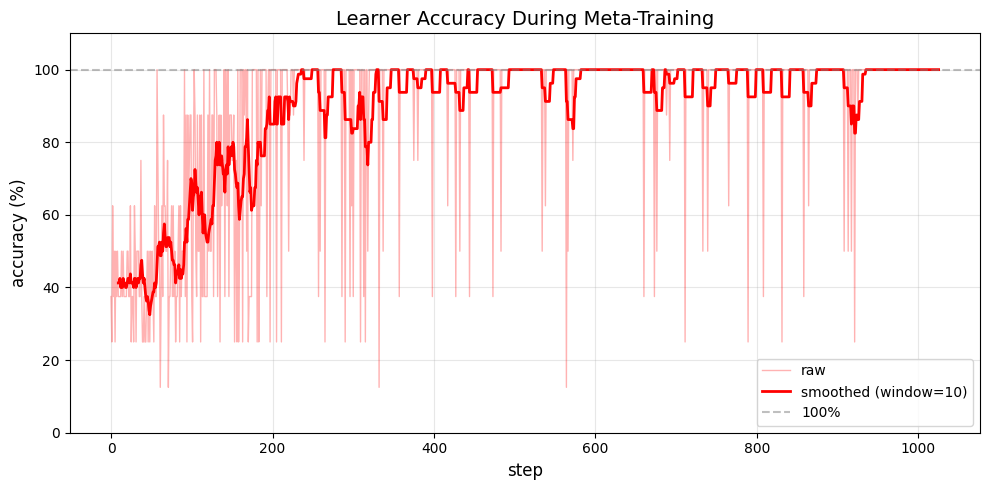

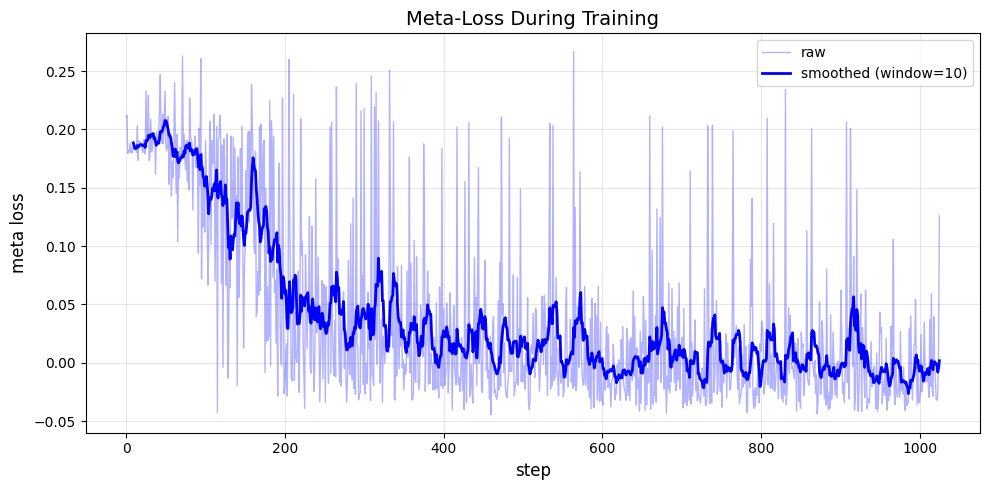

In [80]:
generator_div = Generator(num_classes=2, n_per_class=20)

meta = MetaLearner(
    generator=generator_div,
    learner_class=CNN,
    meta_loss_fn=mlf.meta_loss_mse,
    num_classes=2,
    n_per_class=20,
    regularization_fn=mlf.regularizer_class_diversity,
    reg_parameter=0.1,
    meta_lr=0.05,
    inner_lr=0.5, 
    inner_steps=7,
    stop_after_consecutive_100=100
)

meta.train(steps=2000, visualize_every=0)
meta.plot_accuracy()
meta.plot_meta_loss()
acc_class_diversity = meta.get_accuracy_history()

As can be seen, the classes become more diverse while still preserving locality. In class 1, the defining pattern is a white pixel followed by a black pixel (in that exact order) in one of the two positions, while the other position can contain anything — two black pixels, two gray, one white and one black (except for zero class patterns). Moreover, this pattern may appear either in the left or the right pair. This reflects the inductive bias towards locality: the label is determined by the local structure rather than the global one. The effect of stride 2 is also noticeable — class 0 contains an element with a white pixel followed by a black pixel in the middle, but this does not affect its placement in class 1.

As can be seen, the situation is similar — here, the distinguishing pattern for class 0 consists of a black pixel followed by a white pixel (in that exact order).

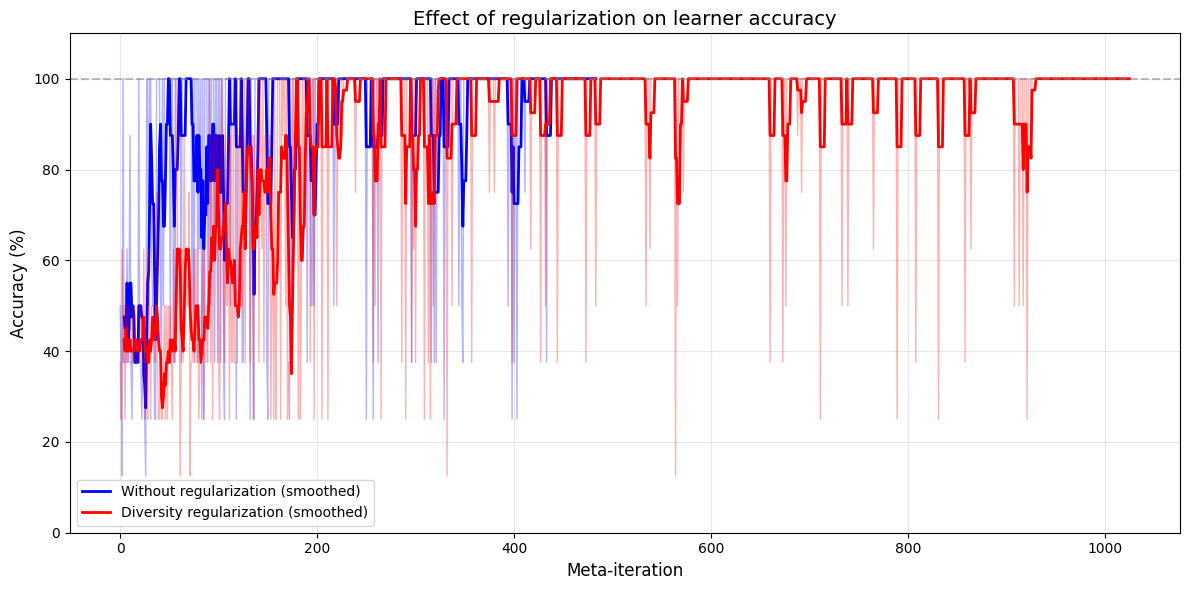

In [150]:
plot_accuracy_comparison(acc_without_reg, acc_class_diversity,
                         labels=["Without regularization", "Diversity regularization"],
                         title="Effect of regularization on learner accuracy")

Let's test the locality property of the resulting dataset. To do this, we'll swap the right and left sides and see how the model trained on the original dataset performs on this data.

In [151]:
def swap_left_right_1x4(x):
    left = x[:, :, :, :2]
    right = x[:, :, :, 2:]
    x_swapped = torch.cat([right, left], dim=-1)
    return x_swapped

In [153]:
num_classes = 2
n_per_class = 20
x = generator_div.forward().detach()
y = torch.arange(num_classes).repeat_interleave(n_per_class)

In [158]:
num_cnns = 1000

results = {
    'original': [],
    'swapped': []
}

for cnn_idx in range(num_cnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_train = x[train_idx]
    y_train = y[train_idx]
    x_test = x[test_idx]
    y_test = y[test_idx]
    
    cnn = CNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
    
    for epoch in range(7):
        optimizer.zero_grad()
        logits = cnn.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    cnn.eval()
    with torch.no_grad():
        logits = cnn.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_original = (preds == y_test).float().mean().item() * 100
    results['original'].append(acc_original)

    x_swapped = swap_left_right_1x4(x_test)
    
    with torch.no_grad():
        logits = cnn.forward(x_swapped)
        preds = logits.argmax(dim=1)
        acc_swapped = (preds == y_test).float().mean().item() * 100
    results['swapped'].append(acc_swapped)
    cnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_swapped = np.mean(results['swapped'])
std_swapped = np.std(results['swapped'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")
print(f"{'Swapped':<15} {mean_swapped:.2f} ± {std_swapped:.2f}")

Data type       Accuracy (%)        
--------------------------------------------------
Original        98.78 ± 8.82                
Swapped         98.78 ± 8.82


Now it's the same, but the model is trained on swapped dataset:

In [159]:
num_cnns = 1000

results = {
    'original': [],
    'swapped': []
}

for cnn_idx in range(num_cnns):    
    total = x.shape[0]
    split = int(0.8 * total)
    torch.manual_seed(int(time.time() * 1000) % 10**9)
    perm = torch.randperm(total)
    train_idx = perm[:split]
    test_idx = perm[split:]
    
    x_swapped = swap_left_right_1x4(x)

    x_train = x_swapped[train_idx]
    y_train = y[train_idx]
    x_test = x_swapped[test_idx]
    y_test = y[test_idx]
    
    cnn = CNN(num_classes=num_classes)
    optimizer = torch.optim.SGD(cnn.parameters(), lr=0.5)
    
    for epoch in range(7):
        optimizer.zero_grad()
        logits = cnn.forward(x_train)
        loss = F.cross_entropy(logits, y_train)
        loss.backward()
        optimizer.step()

    cnn.eval()
    with torch.no_grad():
        logits = cnn.forward(x_test)
        preds = logits.argmax(dim=1)
        acc_swapped = (preds == y_test).float().mean().item() * 100
    results['swapped'].append(acc_swapped)
    
    with torch.no_grad():
        logits = cnn.forward(x[test_idx])
        preds = logits.argmax(dim=1)
        acc_original = (preds == y[test_idx]).float().mean().item() * 100
    results['original'].append(acc_original)
    cnn.train()

mean_original = np.mean(results['original'])
std_original = np.std(results['original'])
mean_swapped = np.mean(results['swapped'])
std_swapped = np.std(results['swapped'])

print(f"{'Data type':<15} {'Accuracy (%)':<20}")
print("-" * 50)
print(f"{'Swapped':<15} {mean_swapped:.2f} ± {std_swapped:.2f}")
print(f"{'Original':<15} {mean_original:.2f} ± {std_original:.2f} {'':<15}")

Data type       Accuracy (%)        
--------------------------------------------------
Swapped         99.08 ± 7.25
Original        99.08 ± 7.25                


Thus, using this toy example, we have shown that our algorithm trains the generator to create datasets that reflect the inductive bias of the model — in this case, the locality of the data.